# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/code/FALL 2025/BEE 4750/hw3-tas27433`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

In [3]:
using Plots, LaTeXStrings

# Problem Setup and Functions For Reuse

# Constants
v, k2, kc, kn = 6.0, 0.55, 0.35, 0.25
Cs = 10.0
d, xmax = 15.0, 50.0
Qr, Qw1, Qw2 = 100000.0, 10000.0, 15000.0
DO_r,  CBOD_r,  NBOD_r  = 7.5, 5.0, 5.0
DO_w1, CBOD_w1, NBOD_w1 = 5.0, 50.0, 35.0
DO_w2, CBOD_w2, NBOD_w2 = 5.0, 45.0, 35.0

# Helper Functions

# Mixing Function
mix(Qa,Ca,Qb,Cb) = (Qa*Ca + Qb*Cb) / (Qa + Qb)

# Streeter-Phelps Function
sp(Cs,k2,kc,kn,DO0,Lc0,Ln0,v,x) = begin
    t  = x ./ v
    e2, ec, en = exp.(-k2 .* t), exp.(-kc .* t), exp.(-kn .* t)
    D0 = Cs - DO0
    D  = D0 .* e2 .+ (kc/(k2-kc))*Lc0 .* (ec .- e2) .+ (kn/(k2-kn))*Ln0 .* (en .- e2)
    Cs .- D
end

# Analytical Curve Function
analytic_curve(; rem1=0.0, rem2=0.0) = begin
    CBOD1, NBOD1 = CBOD_w1*(1-rem1), NBOD_w1*(1-rem1)
    CBOD2, NBOD2 = CBOD_w2*(1-rem2), NBOD_w2*(1-rem2)

    # Segment 1
    DO0_1 = mix(Qr, DO_r,   Qw1, DO_w1)
    Lc0_1 = mix(Qr, CBOD_r, Qw1, CBOD1)
    Ln0_1 = mix(Qr, NBOD_r, Qw1, NBOD1)
    x1    = range(0, d; length=400)
    DO1   = sp(Cs,k2,kc,kn,DO0_1,Lc0_1,Ln0_1,v,x1)

    # Segment 2
    Lc_d, Ln_d, DO_d = Lc0_1*exp(-kc*d/v), Ln0_1*exp(-kn*d/v), DO1[end]
    DO0_2 = mix(Qr+Qw1, DO_d, Qw2, DO_w2)
    Lc0_2 = mix(Qr+Qw1, Lc_d, Qw2, CBOD2)
    Ln0_2 = mix(Qr+Qw1, Ln_d, Qw2, NBOD2)
    x2    = range(d, xmax; length=801)
    DO2   = sp(Cs,k2,kc,kn,DO0_2,Lc0_2,Ln0_2,v, x2 .- d)

    x_all  = vcat(collect(x1), collect(x2)[2:end])
    DO_all = vcat(DO1, DO2[2:end])
    return x_all, DO_all
end

# Numerical Curve Function
numeric_curve(dx; rem1=0.0, rem2=0.0) = begin
    CBOD1, NBOD1 = CBOD_w1*(1-rem1), NBOD_w1*(1-rem1)
    CBOD2, NBOD2 = CBOD_w2*(1-rem2), NBOD_w2*(1-rem2)

    # Setup
    x = 0:dx:xmax; nx = length(x); ix_d = findfirst(==(d), x)
    Lc = zeros(nx); Ln = zeros(nx); D = zeros(nx)

    # Initial Conditions
    DO0   = mix(Qr, DO_r,   Qw1, DO_w1)
    Lc[1] = mix(Qr, CBOD_r, Qw1, CBOD1)
    Ln[1] = mix(Qr, NBOD_r, Qw1, NBOD1)
    D[1]  = Cs - DO0

    # Marching
    for i in 1:ix_d-1
        Lc[i+1] = Lc[i] + dx*(-kc*Lc[i])/v
        Ln[i+1] = Ln[i] + dx*(-kn*Ln[i])/v
        D[i+1]  = D[i]  + dx*(-k2*D[i] + kc*Lc[i] + kn*Ln[i])/v
    end

    # Mix With Second Waste Stream
    DO_d_minus = Cs - D[ix_d]
    DO_d_plus  = mix(Qr+Qw1, DO_d_minus, Qw2, DO_w2)
    Lc[ix_d]   = mix(Qr+Qw1, Lc[ix_d],   Qw2, CBOD2)
    Ln[ix_d]   = mix(Qr+Qw1, Ln[ix_d],   Qw2, NBOD2)
    D[ix_d]    = Cs - DO_d_plus

    # Marching
    for i in ix_d:nx-1
        Lc[i+1] = Lc[i] + dx*(-kc*Lc[i])/v
        Ln[i+1] = Ln[i] + dx*(-kn*Ln[i])/v
        D[i+1]  = D[i]  + dx*(-k2*D[i] + kc*Lc[i] + kn*Ln[i])/v
    end

    return x, Cs .- D
end

# Function to Find Minimum
min_with_loc(x, y) = begin
    i = argmin(y); (y[i], x[i], i)
end


min_with_loc (generic function with 1 method)

Analytical Minimum DO = 3.7556656203626115 (mg/L) at x = 22.35 (km)


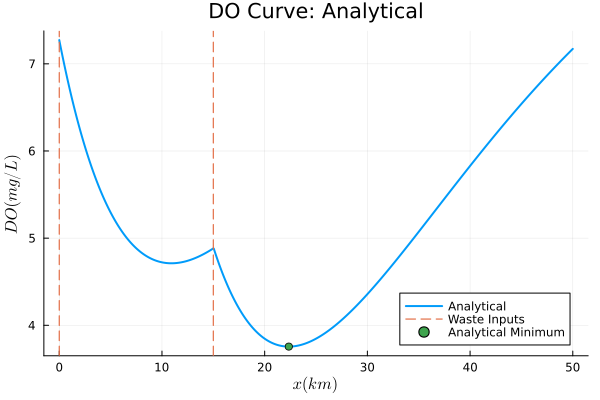

In [4]:
# Problem 1.1
xA, DOA = analytic_curve()                     
DOminA, xminA, _ = min_with_loc(xA, DOA)
println("Analytical Minimum DO = $(DOminA) (mg/L) at x = $(xminA) (km)")

plt = plot(xA, DOA, lw=2, label="Analytical", xlabel=L"x (km)", ylabel=L"DO (mg/L)",title="DO Curve: Analytical")
vline!([0,d], ls=:dash, lw=1.2, label="Waste Inputs")
scatter!([xminA], [DOminA], label="Analytical Minimum")
display(plt)


### Problem 1.1

Analytical Minimum DO = 3.76 (mg/L) at x = 22.35 (km)


The above code does the following,
- Defines our river and wastewater parameters
- Creates a function for mixing concentrations
- Creates a function to solve the Street-Phelps equation
- Creates a function that solves for the analytical curve based on two segments
- Creates a function that solves for the numerical curve based on two segments
- Creates a function that finds the minimum DO value on the river
- With regard to problem 1.1 the code calls the analytical curve to compute the full profile, then uses the minimum function to get the lowest DO and where it occurs and then prints it and plots the DO curve

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

 Numerical Minimum DO = 3.6938634284224072 (mg/L) at x = 22.0 (km)


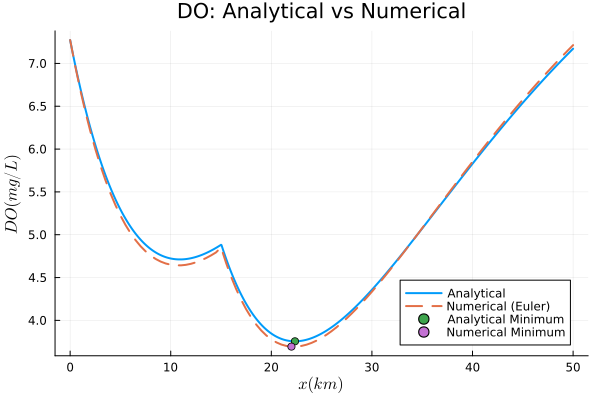

In [5]:
# Problem 1.2
xN, DON = numeric_curve(0.5)                 
DOminN, xminN, _ = min_with_loc(xN, DON)
println(" Numerical Minimum DO = $(DOminN) (mg/L) at x = $(xminN) (km)")

plt2 = plot(xA, DOA, lw=2, label="Analytical", xlabel=L"x (km)", ylabel=L"DO (mg/L)", title="DO: Analytical vs Numerical")
plot!(plt2, xN, DON, ls=:dash, lw=2, label="Numerical (Euler)")
scatter!([xminA], [DOminA], label = "Analytical Minimum")
scatter!([xminN], [DOminN], label = "Numerical Minimum")
display(plt2)

### Problem 1.2 Writeup

We now see that,
-   Analytic min DO = 3.76 (mg/L) at x = 22.35 (km)
-   Numerical Minimum DO = 3.70 (mg/L) at x = 22.0 (km)
-   The DO difference is 0.06 (mg/)
-   The X position difference is 0.35 (km)

With regard to the difference in values between for the minimum DO value this is because,
-   With each timestep, our Euler updates are calculated through a linear equation, however, our decay is exponential, this underestimates the decay of CBOD/NBOD/DO which causes an increase in oxygen demand and causes the DO to become lower than the analytical curve. 

With regard to the difference in values between the X position this is because,
-   In the numerical version, we update each node by a timstep, using the conditions from the previous node. When the waste stream 2 is applied, it gets mixed in instantaneously at that grid point. Analytically, this does not occur, it will mix over time. However, with our numerical version it jumps to a larger oxygen demand, this then carries forward. Now because each new timestep uses an upstream value, the oxygen demand changes the DO at a sooner position than the eaxct solution.

The above code does the following,
- Runs a numerical euler DO simulation a spatial change step of 0.5 km, finds where that numerical minimum occurs, then plots the analytical and numerical curves together to highlight the differences betweent the minimum value and location that is caused by discretization

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

In [6]:
# Problem 1.3

DO_target = 4.0 * 1.05   
min_DO_after(rem1, rem2) = minimum(last(analytic_curve(rem1=rem1, rem2=rem2)))

function find_min_removal(treat_stream::Int; tol=1e-3, maxit=40)
    # finds the minimum removal fraction on the specified stream (1 or 2)
    f(r) = (treat_stream == 1 ? min_DO_after(r, 0.0) : min_DO_after(0.0, r)) - DO_target
    low, high = 0.0, 1.0
    # Check endpoints
    if f(low) ≥ 0; return 0.0, min_DO_after(0,0); end
    if f(high) < 0; return NaN, min_DO_after(1,1); end
    # Bisection 
    for _ in 1:maxit
        mid = (low + high) / 2
        (f(mid) ≥ 0 ? high = mid : low = mid)
        if (high - low) < tol; break; end
    end
    r = high
    return r, (treat_stream == 1 ? min_DO_after(r,0.0) : min_DO_after(0.0,r))
end

r1, DO1 = find_min_removal(1)  
r2, DO2 = find_min_removal(2)  

println("Waste 1 only: $(100*r1)% removal, Minimum  DO = $(DO1) (mg/L)")
println("Waste 2 only: $(100*r2)% removal, Minimum DO = $(DO2) (mg/L)")


Waste 1 only: 27.63671875% removal, Minimum  DO = 4.200533559836975 (mg/L)
Waste 2 only: 21.77734375% removal, Minimum DO = 4.200653050982377 (mg/L)


### Problem 1.3 Writeup

We now see that if only one of these waste streams is treated then,
- Waste 1 only, requires a 27.64% removal
- Waste 2 only, requires a 21.78% removal

The above code does,
- Uses the analytical DO model to iteratively find the minimum % removal of CBOD and NBOD needed at each discharge, ensuring that DO >= 4.2 mg/L everywhere downstream, then reports the required removal and the resulting minimum DO for each case.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

### Problem 1.4 Writeup

We see in our previous plots that the DO sag's minimum typically occurs after the second waste stream, therefore, if we improved the quality of that downstream waste then we would see a raise in the minimum dissolved oxygen where it matters the most.


Other information that could be used before deciding is learning about the variability in the streams in other scenarios, such as seasonal changes or storms, as well a cost comparison between treating just waste stream 2 or both waste streams equally would likely be helpful. Based off of what we have done here, it is unlikely that a conclusion could be made.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [15]:
# Problem 1.5

function min_DO_given_inflow(DO_r_sample; rem1=r1)
    CBOD1, NBOD1 = CBOD_w1*(1-rem1), NBOD_w1*(1-rem1)
    # Segment 1: river (sampled DO) + WS1
    DO0_1 = mix(Qr, DO_r_sample, Qw1, DO_w1)
    Lc0_1 = mix(Qr, CBOD_r,     Qw1, CBOD1)
    Ln0_1 = mix(Qr, NBOD_r,     Qw1, NBOD1)
    x1    = range(0, d; length=300)
    DO1   = sp(Cs,k2,kc,kn,DO0_1,Lc0_1,Ln0_1,v,x1)

    # Segment 2
    Lc_d, Ln_d, DO_d = Lc0_1*exp(-kc*d/v), Ln0_1*exp(-kn*d/v), DO1[end]
    DO0_2 = mix(Qr+Qw1, DO_d, Qw2, DO_w2)
    Lc0_2 = mix(Qr+Qw1, Lc_d, Qw2, CBOD_w2)
    Ln0_2 = mix(Qr+Qw1, Ln_d, Qw2, NBOD_w2)
    x2    = range(d, xmax; length=600)
    DO2   = sp(Cs,k2,kc,kn,DO0_2,Lc0_2,Ln0_2,v, x2 .- d)
    return minimum(vcat(DO1, DO2[2:end]))
end

# Monte Carlo Function
function monte_carlo_fail(n; seed=42)
    rng  = MersenneTwister(seed)
    dist = LogNormal(2.0, 0.15)
    fail_avg = zeros(n)
    fail_se  = zeros(n)

    first_fail = (min_DO_given_inflow(rand(rng, dist)) < 4.0) ? 1.0 : 0.0
    fail_avg[1] = first_fail
    fail_se[1]  = 0.0

    for i in 2:n
        fail_i = (min_DO_given_inflow(rand(rng, dist)) < 4.0) ? 1.0 : 0.0
        fail_avg[i] = (fail_avg[i-1]*(i-1) + fail_i) / i
        p = fail_avg[i]
        fail_se[i] = sqrt(p*(1-p)) / sqrt(i)
    end
    return fail_avg, fail_se
end


n = 10_000
avg_fail, se_fail = monte_carlo_fail(n)
prob   = avg_fail[end]
se2  = se_fail[end]
z   = 1.96
ci  = (max(0.0, prob - z*se2), min(1.0, prob + z*se2))

println("Percent Removal: $(100rem1)%")
println("Estimated Failure Probability = $(prob)%")
println("95% Confidence Interval = $(ci)")
println("N = $n")


Percent Removal: 27.1%
Estimated Failure Probability = 0.0282%
95% Confidence Interval = (0.024955340911343687, 0.03144465908865631)
N = 10000


### Problem 1.5 Writeup

The expected probability and 95% confidence interval that the river fails to comply with the regulatory standard of 4 mg/L is a 0.0282% of failure probability with a confidence interval of (0.025, 0.031). The monte carlo sample size was chosen as 10,000, this is a sufficient size as if we ran more trials the the result would not change noticeably, as 10,000 has lead to an estimte that is converged.

The above code,
- Defines a function that computes the minimum DO along the irver using the streeter-phelps model. Miing, the inflow with discharges and then applying decay rates, retuning the lowest DO value.
- The second function is a monte carlo simulation that runs n trails, where in each trial, a random inflow DO is sampled from a distribution, the minimum DO along the river is recalculated and constituted as a filure if it is below 4 mg/L
- It tracks the average and standard error of the failure rate as the simulation progess, providing an esitmate of the probability that the river violates the standard

## References

List any external references consulted, including classmates.